In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dan eksplorasi data
df = pd.read_csv("data/water_potability.csv")
df = df.dropna()  # Drop karena air adalah data sensitif

In [81]:
# Menyeimbangkan kelas (upsampling class 1)
from sklearn.utils import resample, shuffle
df_0 = df[df['Potability'] == 0]
df_1 = df[df['Potability'] == 1]
df_1_upsampled = resample(df_1, replace=True, n_samples=len(df_0), random_state=42)
df_balanced = shuffle(pd.concat([df_0, df_1_upsampled]), random_state=42)

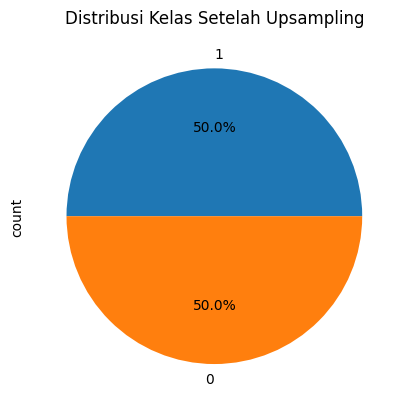

In [82]:
# Cek distribusi kelas
df_balanced.Potability.value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribusi Kelas Setelah Upsampling")
plt.show()

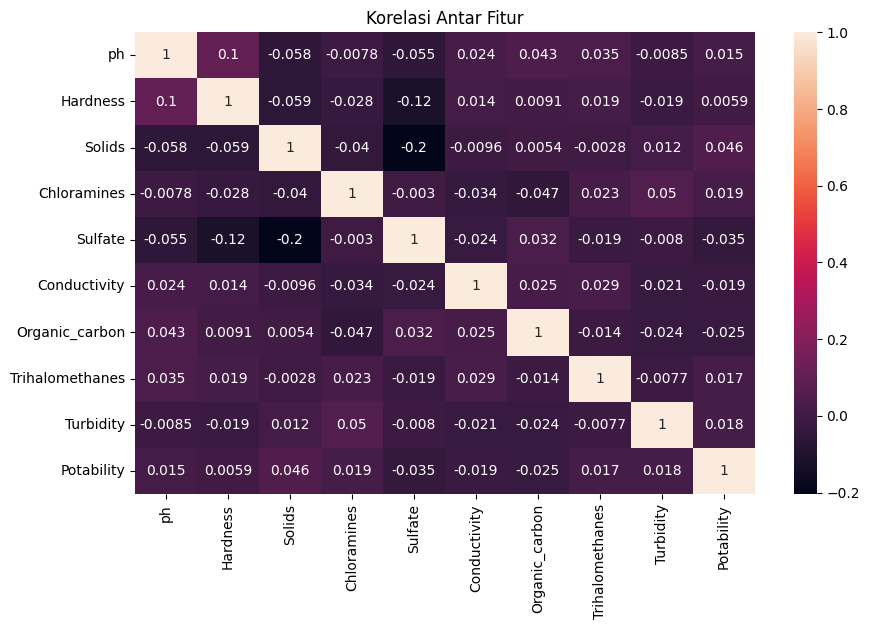

In [83]:
# Korelasi
plt.figure(figsize=(10,6))
sns.heatmap(df_balanced.corr(), annot=True)
plt.title("Korelasi Antar Fitur")
plt.show()

<Axes: xlabel='ph', ylabel='Hardness'>

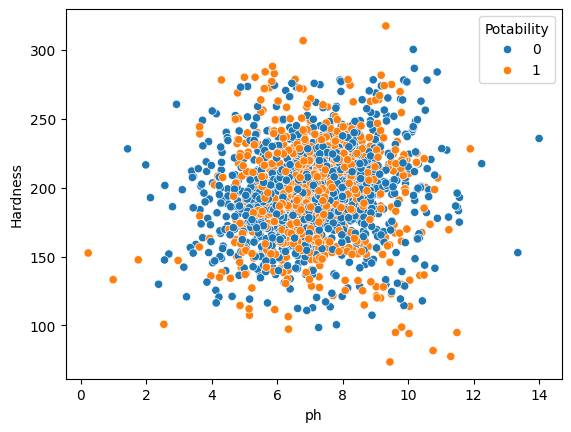

In [84]:
sns.scatterplot(x=df["ph"], y=df["Hardness"], hue=df.Potability,
data=df)

<Axes: xlabel='ph', ylabel='Hardness'>

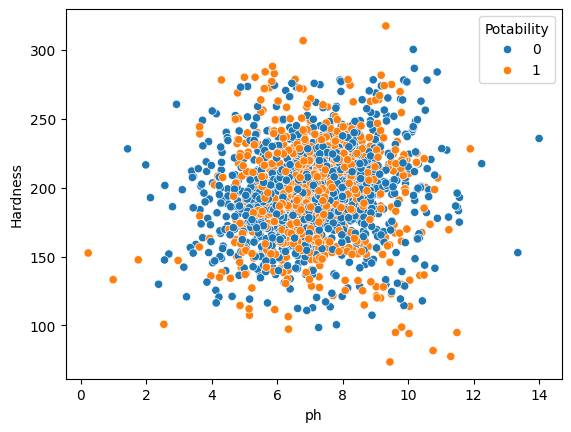

In [85]:
sns.scatterplot(x=df["ph"], y=df["Hardness"], hue=df.Potability,
data=df)

In [86]:
df.corr().abs()['Potability'].sort_values(ascending = False)

Potability         1.000000
Solids             0.040674
Turbidity          0.022682
Chloramines        0.020784
Organic_carbon     0.015567
Conductivity       0.015496
Sulfate            0.015303
ph                 0.014530
Trihalomethanes    0.009244
Hardness           0.001505
Name: Potability, dtype: float64

In [87]:
# Split fitur dan target
X = df_balanced.drop('Potability', axis=1)
y = df_balanced['Potability']

In [88]:
# Standardisasi
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [89]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1, random_state=42, stratify=y)


In [90]:
# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score


In [91]:
from sklearn.metrics import accuracy_score, classification_report
# MODEL SEBELUM TUNING
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier()
}

print("=== Akurasi Sebelum Tuning ===")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name}: {accuracy_score(y_test, y_pred):.2f}")

=== Akurasi Sebelum Tuning ===
Logistic Regression: 0.51
KNN: 0.75
Naive Bayes: 0.53
Decision Tree: 0.80


In [92]:
# Grid search
results = {}
best_models = {}

In [93]:
# Logistic Regression
print("\n🔍 Logistic Regression")
lr = LogisticRegression()
param_lr = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
grid_lr = GridSearchCV(lr, param_lr, cv=5)
grid_lr.fit(X_train, y_train)
best_models['Logistic Regression'] = grid_lr.best_estimator_
results['Logistic Regression'] = grid_lr.best_score_


🔍 Logistic Regression


In [94]:
# KNN
print("\n🔍 KNN")
knn = KNeighborsClassifier()
param_knn = {'n_neighbors': np.arange(1, 50), 'weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(knn, param_knn, cv=5)
grid_knn.fit(X_train, y_train)
best_models['KNN'] = grid_knn.best_estimator_
results['KNN'] = grid_knn.best_score_


🔍 KNN


In [95]:
# Naive Bayes (tidak perlu tuning)
print("\n🔍 Naive Bayes")
nb = GaussianNB()
nb.fit(X_train, y_train)
best_models['Naive Bayes'] = nb
results['Naive Bayes'] = nb.score(X_train, y_train)  # pakai training karena tidak cross-validation



🔍 Naive Bayes


In [96]:
# Decision Tree
print("\n🔍 Decision Tree")
dt = DecisionTreeClassifier()
param_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth':np.arange(1, 50),
    'min_samples_leaf':[1,2,4,5,10,20,30,40,80,100]
}
grid_dt = GridSearchCV(dt, param_dt, cv=5)
grid_dt.fit(X_train, y_train)
best_models['Decision Tree'] = grid_dt.best_estimator_
results['Decision Tree'] = grid_dt.best_score_


🔍 Decision Tree


c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



📊 Evaluasi Semua Model di Test Set:

Model: Logistic Regression
Akurasi: 50.83%
              precision    recall  f1-score   support

           0       0.51      0.53      0.52       120
           1       0.51      0.48      0.50       120

    accuracy                           0.51       240
   macro avg       0.51      0.51      0.51       240
weighted avg       0.51      0.51      0.51       240



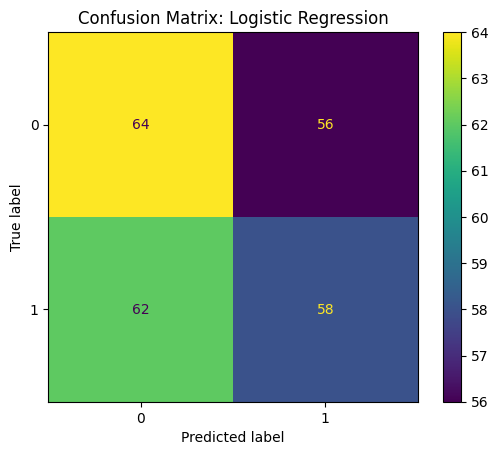


Model: KNN
Akurasi: 80.83%
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       120
           1       0.79      0.83      0.81       120

    accuracy                           0.81       240
   macro avg       0.81      0.81      0.81       240
weighted avg       0.81      0.81      0.81       240



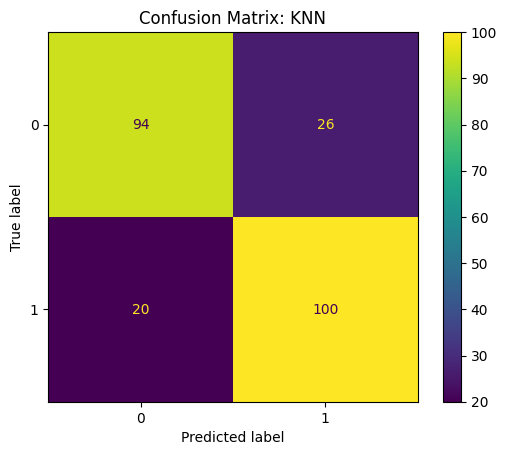


Model: Naive Bayes
Akurasi: 52.92%
              precision    recall  f1-score   support

           0       0.52      0.62      0.57       120
           1       0.54      0.44      0.48       120

    accuracy                           0.53       240
   macro avg       0.53      0.53      0.53       240
weighted avg       0.53      0.53      0.53       240



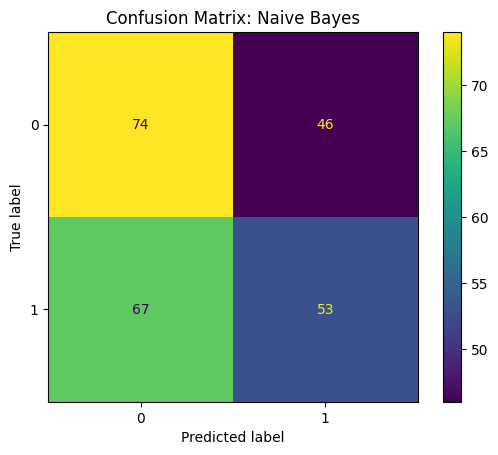


Model: Decision Tree
Akurasi: 78.33%
              precision    recall  f1-score   support

           0       0.85      0.69      0.76       120
           1       0.74      0.88      0.80       120

    accuracy                           0.78       240
   macro avg       0.79      0.78      0.78       240
weighted avg       0.79      0.78      0.78       240



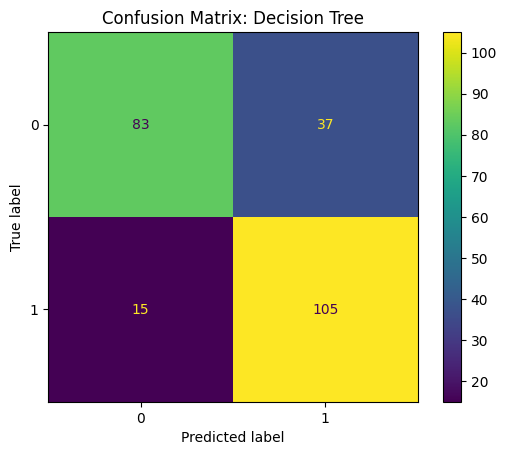

In [97]:
# Evaluasi semua model di test set
print("\n📊 Evaluasi Semua Model di Test Set:")
for name, model in best_models.items():
    print(f"\nModel: {name}")
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"Akurasi: {acc:.2f}%")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot()
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


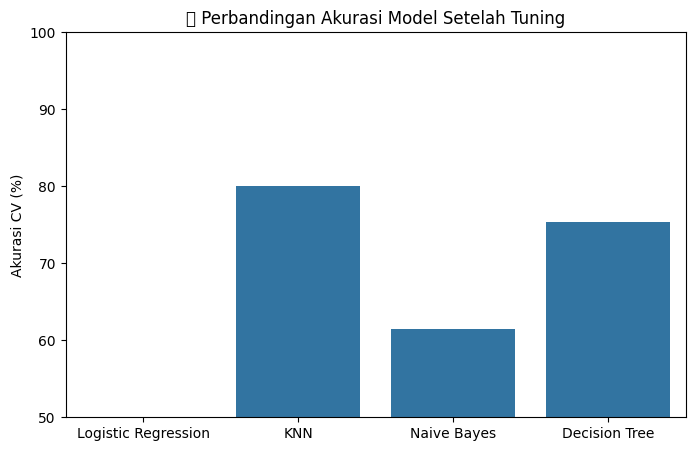

In [98]:
# Grafik perbandingan akurasi (CV)
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=[v*100 for v in results.values()])
plt.ylabel("Akurasi CV (%)")
plt.title("📈 Perbandingan Akurasi Model Setelah Tuning")
plt.ylim(50, 100)
plt.show()

In [99]:
# Model terbaik
best_model_name = max(results, key=results.get)
print(f"\n✅ Model terbaik berdasarkan cross-validation adalah: {best_model_name} dengan akurasi {results[best_model_name]*100:.2f}%")


✅ Model terbaik berdasarkan cross-validation adalah: KNN dengan akurasi 80.00%
